# **Experimento de regresión**

Aprendizaje supervisado con una "y" numérica. Que pueden ser precios de activos, periodos de tiempo, temperatura, ahora es un valor esperado del proceso. La Y puede ser:

- **Tabular:** Se encuentra la información en una tabla, una "y" descrita por medio de las diversa x's. y ~ x 

- **Seriada:** Vector o arreglo donde se tiene a la "y" definida por una variable que es el tiempo. No tengo en una serie de tiempo un conjunto de x que definan y; por lo que debo buscar una forma de tranformarlas.

El experimento de regresión es similar al experimento de clasificación, donde se tienen 2 fases. 

* Entrenamiento o ajuste: Devuelve uno o unos modelos ajustados los cuales se van a presentar en la fase de validación 
* Validación: hace la comparación

La comparación no se mide por conteo como en clasificación, sino con distancia o diferecnias.

Son los más difíciles de ajustar, los modelos que podemos ajustar son:

* Regresión lineal
* K-vecinos
* Máquinas de soporte vectorial
* Árboles de decisión 
* Modelos de ensamble
* Redes neuronales artificiales

**En el proceso de entrenamiento...**

* Tratamienot de nulos --> se mantiene igual
* Exploración de variables --> se mantiene 
* Separación entre entrenamiento- validación --> se mantiene
* Blancear la y --> NO se mantiene
* Desemepeño del modelo --> se mantien aunque con variaciones

En la regresión, el balanceo no es una estrategia de entrenamiento. En este caso nuestra variable no tiene escenarios, tiene valores, y nos interesa que el modelo reconozca la frecuencia de aparición de los diversos valores.

El modelo se va a llevar a opración: se le va a pedir a la estrategia de operación, ver qué pasos debo tener en cuenta para llevarlo a un proceso de MLOps.

**Desempeño de regresión** Varias formas de hacerlo:

* **Ajuste cuadráctico (R^2):** Es una diferencia. Desplazamiento entre el valor real y su pronóstico. En numerador se identifica qué tanto las predicciones se alejan del valor real. También cuanto se aleja el valor de la expectativa de la y (denominador)

Puede tomar valores de -∞ a 1. Un R^2 negativo, indica que las variables x con las cuales fueron definidos los posibles escenarios del proceso no son suficientemente predictivas para los valores de y que estpy esperando. No necesariamente significa que el modelo sea malo, solo que puede tender a fallar.

<u>Buscamos un R^2 que tienda a 1.</u>

* **Error cuadráticó medio (MSE):** Divide por la cantidad de muestras y suma las diferencias cuadráticas. Me va a dar en unidades cuadradas. Trata de identificar un rango dentro del cual se mueve la variable. 

<u>Buscamos un MSE que tienda a 0</u>

* **Raiz del error cuadrático medio (RMSE):** Sacarle raíz cuadrada al MSE.

<u>Buscamos un RMSE que tienda a 0</u>

No que sean 0 o 1, que tiendan.

* **Error medio absoluto (MAE):** Es el promedio, en este caso, se utiliza el valor absoluto, también buscamos que tienda a 0

* **Porcentaje del error medio absoluto (MAPE):** calcula la diferecnia absoluta relativa. Qué tanto se está separando en proporción. Buscamos un MAPE que tienda a 0 porque es un error.

Para mirar probabilida, sería con un R^2 positivo o con el inverso del MAPE. Probabilidad = 1 - MAPE

# **1. Entendimiento del problema** 

Garments Industry es una compañía del sector textil con muchas actividades manuales. Su éxito está en que las prendas son "hechas a mano", por lo que medir la productividad de sus empleados se vuelve esencial para mejorar las utilidades de la organización. Es por esto que la compañía quiere estimar los niveles de productividad de sus empleados para mejorar la operación y mantener los ingresos esperados, además, identificar herramientas para mejorar el día a día de sus empleados.

# **2. Enfoque analítico**
Construir un modelo de regresión para predecir la productividad de cada emepelado con un MAPE< 20% (probabilidad superior al 80%)

# **3. Requerimientos de datos**

- Se requieren datos del trabajador en su puesto de trabajo particular
- Se requieren mediciones del puesto de trabajo (tiempo, cantidad de prendas, momentos de ocio, cantidad de personas)
- Se requiere una medición inicial de la productividad (supervisado)

# **4. Recolección de datos**
- date: Fecha de medición de la prodcutividad
- quarter: trimestre de la medición
- department: área de trabajo en particular
- day: nombre del día en que se hizo la medición
- team: número del equipo de trabajo
- target_productivity: productividad objetivo del área de trabajo
- smv: valor de timepo estándar en minutos de la actividad.
- wip: cantidad de trabajo en proceso (unidades)
- over_time: tiempo general de operación
- incentivo: % de incentivos al área de trabajo
- idle_time: tiempo de parada
- idle_men: cantidad de trabajadores quietos en el tiempo de parada
- no_of_style_change: cantidad de cambios de estilo en la producción
- no_of_workers: cantidad total de trabajadores
- actual_productivity: Productividad actual (y) 

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")
data = pd.read_csv('garments_worker_productivity.csv')
data

,date,quarter,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
0,1/1/2015,Quarter1,sweing,Thursday,8,0.80,26.16,1108.0,7080,98,0.0,0,0,59.0,0.940725
1,1/1/2015,Quarter1,finishing,Thursday,1,0.75,3.94,NaN,960,0,0.0,0,0,8.0,0.886500
2,1/1/2015,Quarter1,sweing,Thursday,11,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
3,1/1/2015,Quarter1,sweing,Thursday,12,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
4,1/1/2015,Quarter1,sweing,Thursday,6,0.80,25.90,1170.0,1920,50,0.0,0,0,56.0,0.800382
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1192,3/11/2015,Quarter2,finishing,Wednesday,10,0.75,2.90,NaN,960,0,0.0,0,0,8.0,0.628333
1193,3/11/2015,Quarter2,finishing,Wednesday,8,0.70,3.90,NaN,960,0,0.0,0,0,8.0,0.625625
1194,3/11/2015,Quarter2,finishing,Wednesday,7,0.65,3.90,NaN,960,0,0.0,0,0,8.0,0.625625
1195,3/11/2015,Quarter2,finishing,Wednesday,9,0.75,2.90,NaN,1800,0,0.0,0,0,15.0,0.505889


In [2]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date                   1197 non-null   object 
 1   quarter                1197 non-null   object 
 2   department             1197 non-null   object 
 3   day                    1197 non-null   object 
 4   team                   1197 non-null   int64  
 5   targeted_productivity  1197 non-null   float64
 6   smv                    1197 non-null   float64
 7   wip                    691 non-null    float64
 8   over_time              1197 non-null   int64  
 9   incentive              1197 non-null   int64  
 10  idle_time              1197 non-null   float64
 11  idle_men               1197 non-null   int64  
 12  no_of_style_change     1197 non-null   int64  
 13  no_of_workers          1197 non-null   float64
 14  actual_productivity    1197 non-null   float64
dtypes: f

# **5. Entendimiento de los datos**

- Conocer nuestra variable y
- Identificar datos nulos
- Análisis univariado y multivariado

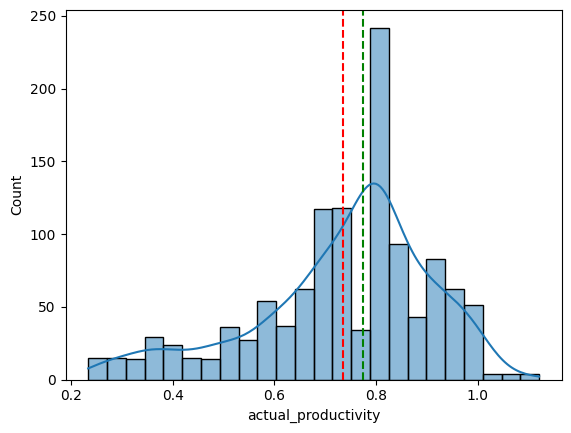

In [3]:
import matplotlib.pyplot as plt
import seaborn as sb
sb.histplot(data= data, x='actual_productivity', kde=True)
plt.axvline(x= data.actual_productivity.mean(), color='red', linestyle='dashed')
plt.axvline(x= data.actual_productivity.median(), color='green', linestyle='dashed')
plt.show()

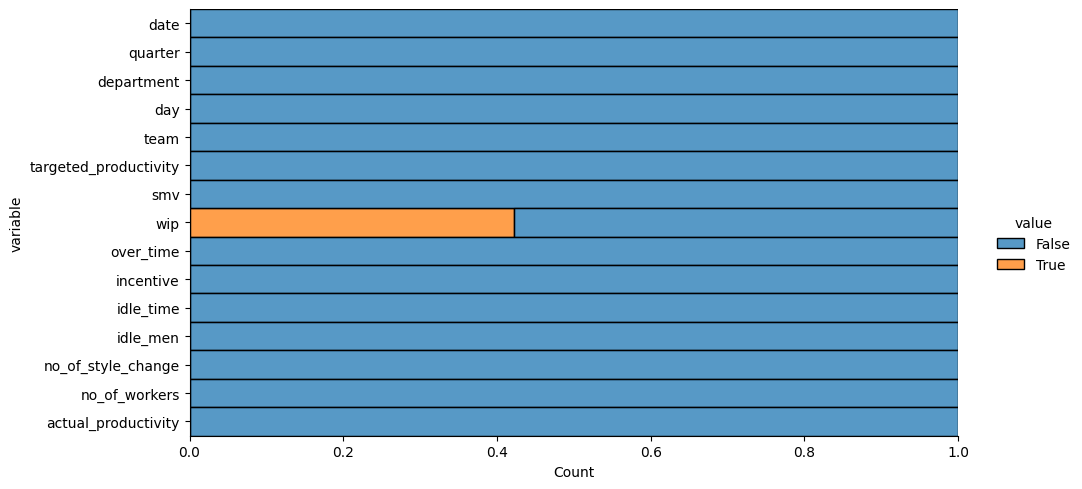

In [4]:
# datos nulos
data.isnull().melt().pipe(lambda df: sb.displot(data=df, y='variable', hue='value', multiple='fill', aspect=2))
plt.show()

Tenemos casi el 40% en datos nulos y aunque la teoría nos dice que la eliminemos, debemos tener en cuenta la naturaleza del negocio, es una variable bastante importante y es mejor en este caso imputar.

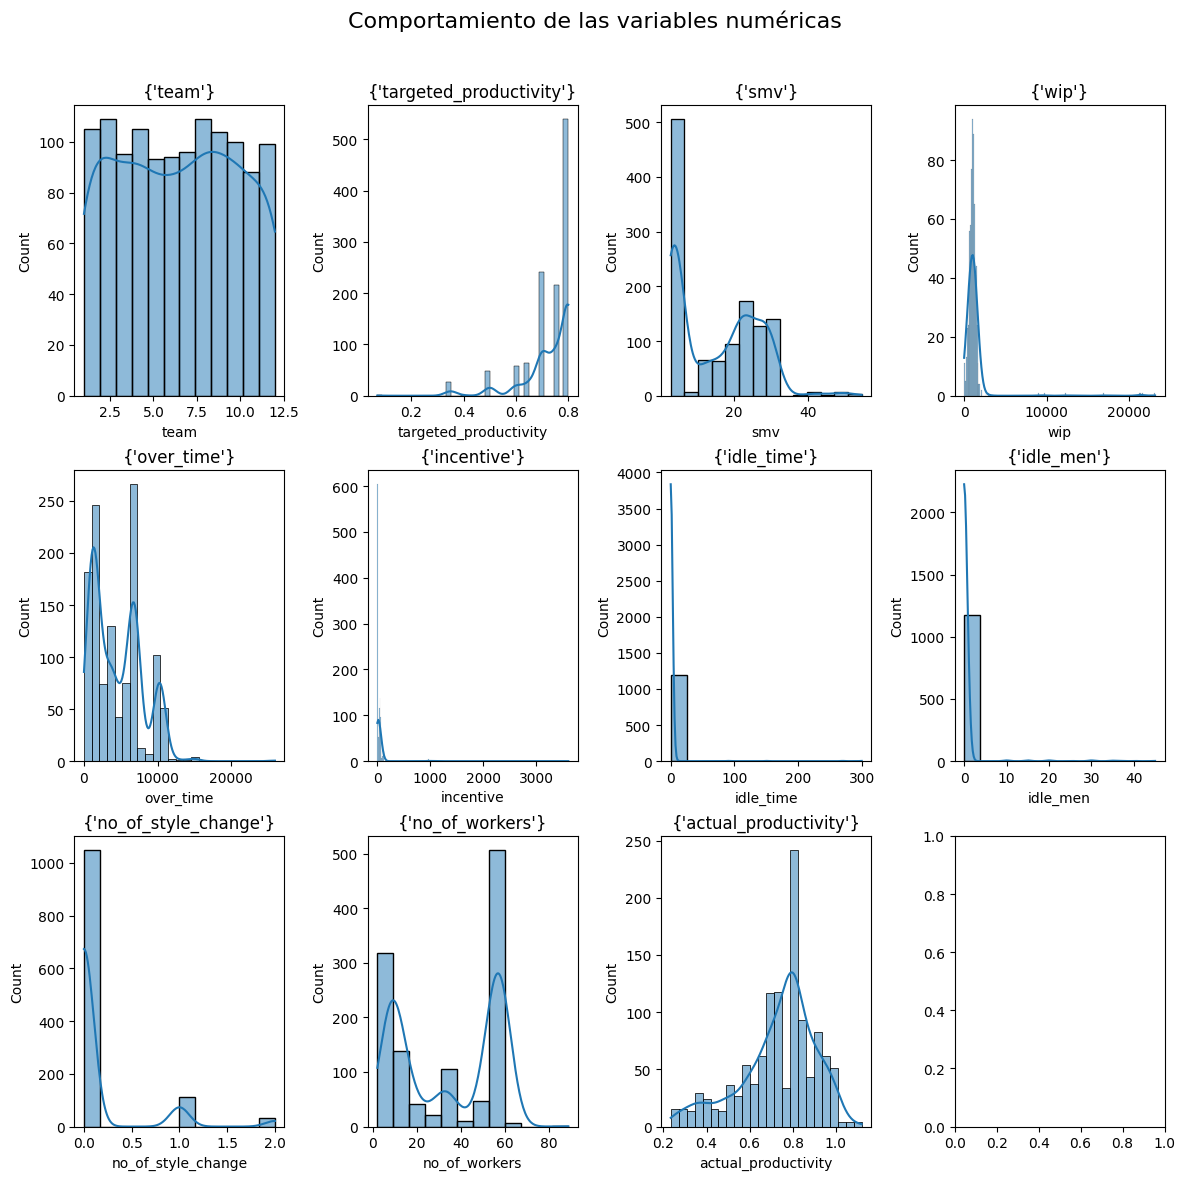

In [5]:
# Histogramas de frecuencias
fig, ax = plt.subplots(3, 4, figsize=(12, 12))
ax = ax.flat
num_col = data.select_dtypes(include = ['float64', 'int64'] ).columns
for i, col in enumerate(num_col):
    sb.histplot(data=data, x=col, kde=True, ax=ax[i])
    ax[i].set_title({col})
fig.tight_layout()
fig.subplots_adjust(top=0.9)
fig.suptitle('Comportamiento de las variables numéricas', fontsize=16)
plt.show()

Traer variables categoricas, y el dataframe imputado por método recursivo.

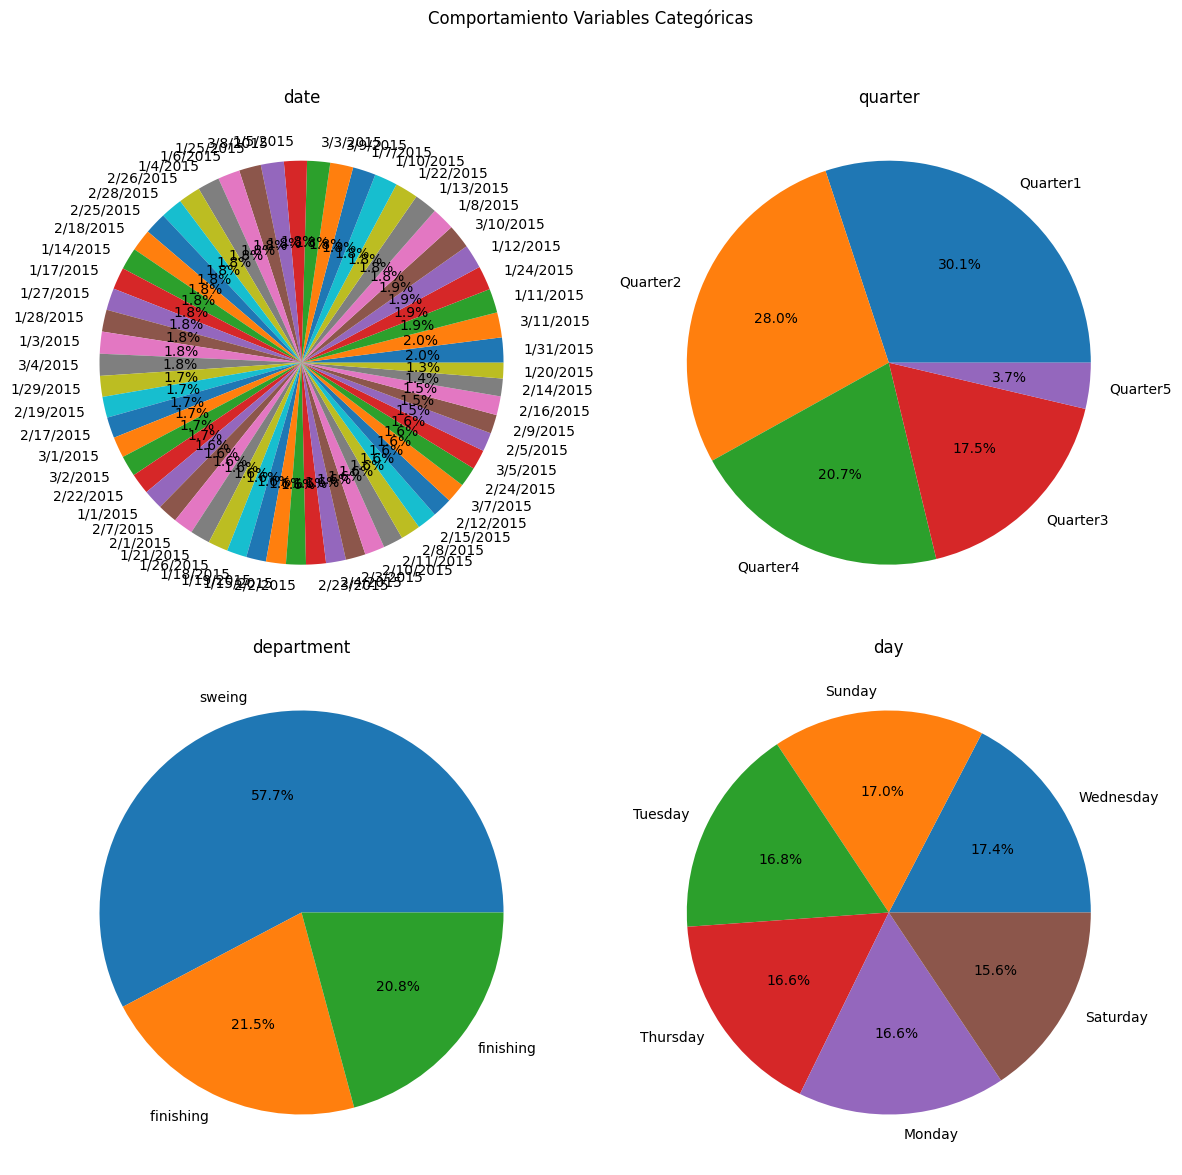

In [6]:
##GRÁFICOS DE TORTA
fig, ax = plt.subplots(2, 2, figsize = (12, 12))
ax = ax.flat
cat_col = data.select_dtypes(include = ['object']).columns
for i, col in enumerate(cat_col):
    ax[i].pie(x = data[col].value_counts(), labels = data[col].value_counts().index, autopct = '%0.1f%%')
    ax[i].set_title(col)
fig.tight_layout()
fig.subplots_adjust(top = 0.9)
fig.suptitle("Comportamiento Variables Categóricas")
plt.show()

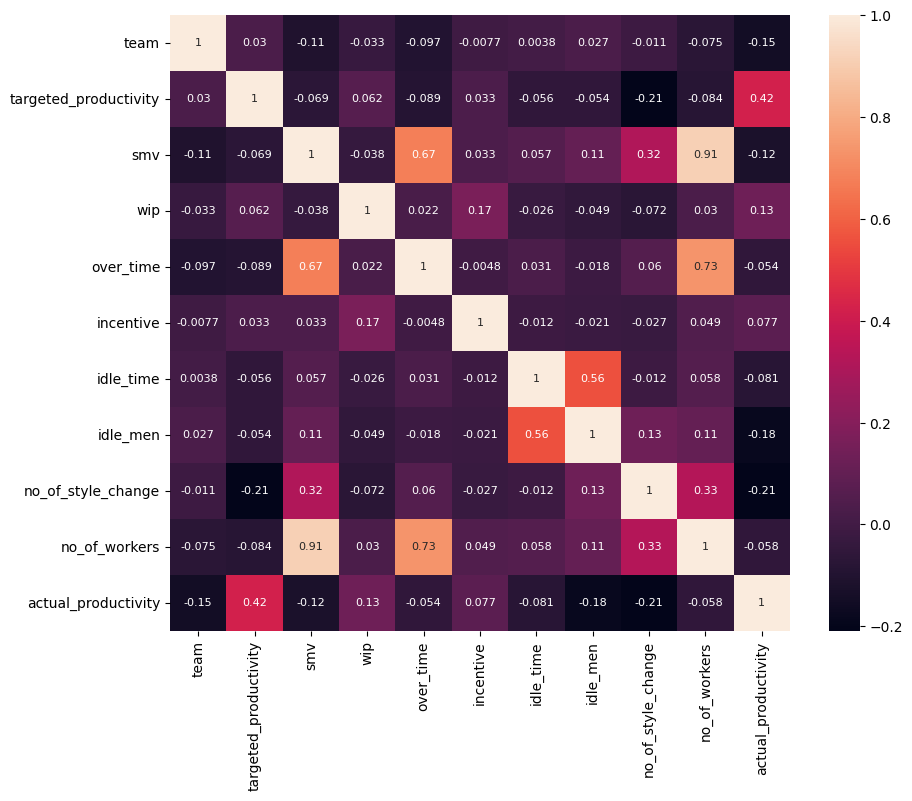

In [7]:
plt.figure(figsize=(10,8))
sb.heatmap(data.corr(numeric_only=True), annot=True, annot_kws={"size": 8})
plt.show()

# **6 Preparación de los datos**

In [8]:
import sklearn 
categorical_cols = data.select_dtypes(include='object').columns
categorical_transformer = sklearn.compose.make_column_transformer((sklearn.preprocessing.OrdinalEncoder(), categorical_cols), remainder='passthrough')
categorical_transformer

,transformers,"[('ordinalencoder', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,categories,'auto'
,dtype,<class 'numpy.float64'>
,handle_unknown,'error'


In [9]:
data_transformed = pd.DataFrame(categorical_transformer.fit_transform(data), 
                                 columns=categorical_transformer.get_feature_names_out(),
                                 index=data.index).rename(columns= lambda x: x.removeprefix('ordinalencoder__')).rename(columns= lambda x: x.removeprefix('remainder__'))
data_transformed.head()

,date,quarter,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
0,0.0,0.0,2.0,3.0,8.0,0.80,26.16,1108.0,7080.0,98.0,0.0,0.0,0.0,59.0,0.940725
1,0.0,0.0,1.0,3.0,1.0,0.75,3.94,NaN,960.0,0.0,0.0,0.0,0.0,8.0,0.886500
2,0.0,0.0,2.0,3.0,11.0,0.80,11.41,968.0,3660.0,50.0,0.0,0.0,0.0,30.5,0.800570
3,0.0,0.0,2.0,3.0,12.0,0.80,11.41,968.0,3660.0,50.0,0.0,0.0,0.0,30.5,0.800570
4,0.0,0.0,2.0,3.0,6.0,0.80,25.90,1170.0,1920.0,50.0,0.0,0.0,0.0,56.0,0.800382


In [10]:
# Imputación recursiva 
import sklearn
from sklearn.tree import DecisionTreeRegressor
from sklearn.experimental import enable_iterative_imputer  
recursive_imputer = sklearn.impute.IterativeImputer(estimator= DecisionTreeRegressor(),
                                                    initial_strategy='mean',
                                                    max_iter=10)
data_recursive_df = pd.DataFrame(recursive_imputer.fit_transform(data_transformed).round(2),
                                  columns=data_transformed.columns, 
                                  index=data_transformed.index)
data_recursive_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date                   1197 non-null   float64
 1   quarter                1197 non-null   float64
 2   department             1197 non-null   float64
 3   day                    1197 non-null   float64
 4   team                   1197 non-null   float64
 5   targeted_productivity  1197 non-null   float64
 6   smv                    1197 non-null   float64
 7   wip                    1197 non-null   float64
 8   over_time              1197 non-null   float64
 9   incentive              1197 non-null   float64
 10  idle_time              1197 non-null   float64
 11  idle_men               1197 non-null   float64
 12  no_of_style_change     1197 non-null   float64
 13  no_of_workers          1197 non-null   float64
 14  actual_productivity    1197 non-null   float64
dtypes: f

In [11]:
data_imputed = data_recursive_df.copy()
data_imputed[categorical_cols] = (categorical_transformer.named_transformers_.ordinalencoder.inverse_transform(X = data_recursive_df[categorical_cols]))  
data_imputed

,date,quarter,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
0,1/1/2015,Quarter1,sweing,Thursday,8.0,0.80,26.16,1108.0,7080.0,98.0,0.0,0.0,0.0,59.0,0.94
1,1/1/2015,Quarter1,finishing,Thursday,1.0,0.75,3.94,813.0,960.0,0.0,0.0,0.0,0.0,8.0,0.89
2,1/1/2015,Quarter1,sweing,Thursday,11.0,0.80,11.41,968.0,3660.0,50.0,0.0,0.0,0.0,30.5,0.80
3,1/1/2015,Quarter1,sweing,Thursday,12.0,0.80,11.41,968.0,3660.0,50.0,0.0,0.0,0.0,30.5,0.80
4,1/1/2015,Quarter1,sweing,Thursday,6.0,0.80,25.90,1170.0,1920.0,50.0,0.0,0.0,0.0,56.0,0.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1192,3/11/2015,Quarter2,finishing,Wednesday,10.0,0.75,2.90,434.0,960.0,0.0,0.0,0.0,0.0,8.0,0.63
1193,3/11/2015,Quarter2,finishing,Wednesday,8.0,0.70,3.90,434.0,960.0,0.0,0.0,0.0,0.0,8.0,0.63
1194,3/11/2015,Quarter2,finishing,Wednesday,7.0,0.65,3.90,434.0,960.0,0.0,0.0,0.0,0.0,8.0,0.63
1195,3/11/2015,Quarter2,finishing,Wednesday,9.0,0.75,2.90,434.0,1800.0,0.0,0.0,0.0,0.0,15.0,0.51


In [12]:
data_mod = data_imputed.drop(['incentive', 'team', 'idle_men', 'idle_time', 'no_of_style_change', 'no_of_workers'], axis=1)
data_mod['department'].replace({'finishing ': 'finishing'}, inplace=True)
data_mod['date'] = pd.to_datetime(data_mod['date'], format='%m/%d/%Y')
data_mod['num_day'] = [i.day for i in data_mod['date']]
data_mod['month'] = [i.month for i in data_mod['date']]
data_mod.drop('date', axis=1, inplace=True)
data_mod.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   quarter                1197 non-null   object 
 1   department             1197 non-null   object 
 2   day                    1197 non-null   object 
 3   targeted_productivity  1197 non-null   float64
 4   smv                    1197 non-null   float64
 5   wip                    1197 non-null   float64
 6   over_time              1197 non-null   float64
 7   actual_productivity    1197 non-null   float64
 8   num_day                1197 non-null   int64  
 9   month                  1197 non-null   int64  
dtypes: float64(5), int64(2), object(3)
memory usage: 93.6+ KB


Variables candidatas a ser ignoradas en numéricas incentivos, las dos idle y non style change y team

variables categóricas: vamos a extraer mes y días de la variable date y corregir el error de datos en department

In [13]:
data_mod

,quarter,department,day,targeted_productivity,smv,wip,over_time,actual_productivity,num_day,month
0,Quarter1,sweing,Thursday,0.80,26.16,1108.0,7080.0,0.94,1,1
1,Quarter1,finishing,Thursday,0.75,3.94,813.0,960.0,0.89,1,1
2,Quarter1,sweing,Thursday,0.80,11.41,968.0,3660.0,0.80,1,1
3,Quarter1,sweing,Thursday,0.80,11.41,968.0,3660.0,0.80,1,1
4,Quarter1,sweing,Thursday,0.80,25.90,1170.0,1920.0,0.80,1,1
...,...,...,...,...,...,...,...,...,...,...
1192,Quarter2,finishing,Wednesday,0.75,2.90,434.0,960.0,0.63,11,3
1193,Quarter2,finishing,Wednesday,0.70,3.90,434.0,960.0,0.63,11,3
1194,Quarter2,finishing,Wednesday,0.65,3.90,434.0,960.0,0.63,11,3
1195,Quarter2,finishing,Wednesday,0.75,2.90,434.0,1800.0,0.51,11,3


In [14]:
from sklearn.compose import ColumnTransformer as columnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.pipeline import Pipeline

num_col = data_mod.select_dtypes(include=['int64', 'float64']).columns.to_list()
cat_col = data_mod.select_dtypes(include=['object']).columns.to_list()

num_transformer = Pipeline(steps=[('scaler', MinMaxScaler())])
cat_transformer = Pipeline(steps=[('encoder', OneHotEncoder())])

preprocessor = columnTransformer(transformers=[('num', num_transformer, num_col),
                                                ('cat', cat_transformer, cat_col)], remainder='passthrough')

preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,feature_range,"(0, ...)"
,copy,True
,clip,False


In [15]:
data_pre = preprocessor.fit_transform(data_mod)
cod_cat = preprocessor.named_transformers_['cat']['encoder'].get_feature_names_out(cat_col)
label = np.concatenate((num_col, cod_cat))
data_pro = pd.DataFrame(data_pre, columns=label)
data_pro.head()

,targeted_productivity,smv,wip,over_time,actual_productivity,num_day,month,quarter_Quarter1,quarter_Quarter2,quarter_Quarter3,quarter_Quarter4,quarter_Quarter5,department_finishing,department_sweing,day_Monday,day_Saturday,day_Sunday,day_Thursday,day_Tuesday,day_Wednesday
0,1.000000,0.450252,0.047631,0.273148,0.797753,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.931507,0.020132,0.034869,0.037037,0.741573,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,1.000000,0.164731,0.041575,0.141204,0.640449,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3,1.000000,0.164731,0.041575,0.141204,0.640449,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
4,1.000000,0.445219,0.050314,0.074074,0.640449,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0


In [16]:
x = data_pro.drop('actual_productivity', axis=1)
y = data_pro[['actual_productivity']]

El tamaño del conjunto de entrenamiento es: (359, 19)
Y el tamaño del conjunto de validación es: (838, 19)


<Axes: xlabel='actual_productivity', ylabel='Count'>

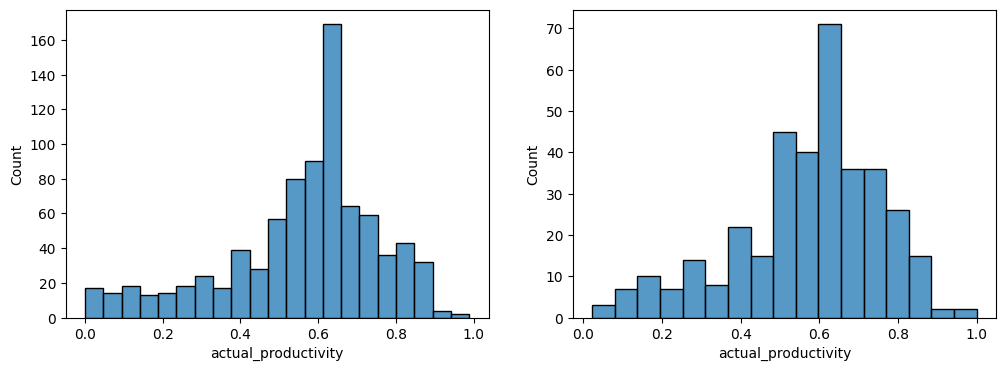

In [17]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.7, random_state=123)
print(f'El tamaño del conjunto de entrenamiento es: {x_train.shape}\nY el tamaño del conjunto de validación es: {x_test.shape}')
fig, ax = plt.subplots(1,2, figsize=(12,4))
sb.histplot(data = y_test, x='actual_productivity', ax = ax[0])
sb.histplot(data = y_train, x='actual_productivity', ax = ax[1])


# **Modelos de regresión:**

* **Regresión lineal:** El objetivo es obtener una ecuación de linea donde beta 0 es el intercepto con el eje y y beta  como la cantidad de información que sooprta x1 a y. Encontrar el valor de Bi que minimice (aprendizaje de máquina) el error del ajuste (puede ser cuadrático o absoluto). Es el único método de aprendixaje de maquina que tiene solución analítica. Los demás métodos tienen soluciones recursivas. Es en el unico que puedo encontrar la derivada, para llevarla a 0 y encontrar el mínimo.
Es de las pocos metodos de machine learning que no cuenta con estados aleatorios y no tiene hiperparámetros porque su solución es analítica.



# **7. Modelado**

- Regresión lineal
- K vecinos más cercanos
- Máquinas de soporte vectorial
- Árboles de decisión
- Random forest
- AdaBoost
- Gradient Boosting
- Percepción multicapa

# **8.Validación**
- Ajuste cuadrático
- Raíz del error cuadrático medio
- Error medio absoluto
- Porcentaje del error medio absoluto (MAPE)

In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor

from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# **Regresión lienal**

In [1]:
# Regresión lineal
modelo_1 = LinearRegression()
modelo_1.fit(x_train, y_train)

NameError: name 'LinearRegression' is not defined

In [20]:
modelo_1.coef_

array([[ 0.47348296, -0.08318395,  0.22624513,  0.1129979 ,  0.29354872,
        -0.01445032,  0.13122572,  0.07304742, -0.02758735, -0.12730934,
        -0.04937645,  0.01448955, -0.01448955, -0.01343251,  0.000897  ,
         0.0055238 , -0.01274879,  0.0292546 , -0.00949411]])

In [21]:
modelo_1.intercept_

array([0.00026621])

**En regresión lineal no se hace la búsqueda de hiperparámetros**

Las métricas de desemepeño en entrenamiento para la regresión lienal son:
R2: 0.19428031568569815
RMSE: 0.16601783564842051
MAE: 0.12018189828602517
MAPE: 0.461152558660457


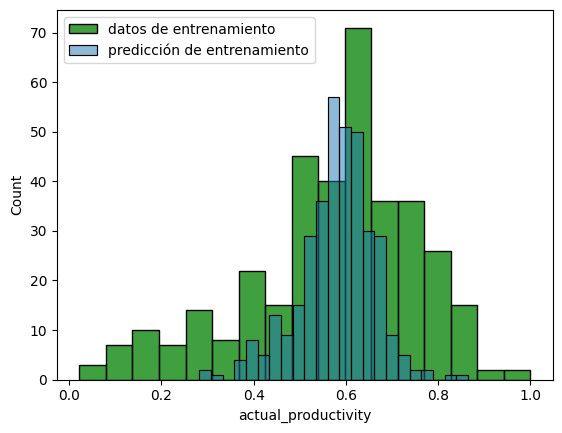

In [22]:
pred_train_1 = modelo_1.predict(x_train)
pred_test_1 = modelo_1.predict(x_test)
# vamos a desescalar nuestras variables para obtener los valores reales
pred_train_des_1 = pred_train_1 * (np.max(y) - np.min(y)) + np.min(y)
pred_test_des_1 = pred_test_1 * (np.max(y) - np.min(y)) + np.min(y)
y_train_des = y_train * (np.max(y) - np.min(y)) + np.min(y)
y_test_des = y_test * (np.max(y) - np.min(y)) + np.min(y)
r2_train_1 = r2_score(y_train_des, pred_train_des_1)
rmse_train_1 = root_mean_squared_error(y_train_des, pred_train_des_1)
mae_train_1 = mean_absolute_error(y_train_des, pred_train_des_1)
mape_train_1 = mean_absolute_percentage_error(y_train_des, pred_train_des_1)
print(f'Las métricas de desemepeño en entrenamiento para la regresión lienal son:\nR2: {r2_train_1}\nRMSE: {rmse_train_1}\nMAE: {mae_train_1}\nMAPE: {mape_train_1}')
sb.histplot(data= y_train_des, x= 'actual_productivity',color='green', label='datos de entrenamiento')
sb.histplot(pred_train_des_1, label='predicción de entrenamiento')
plt.legend()
plt.show()

si lo vemos con el mape se está equivocando el 46% de las veces.

r2 entre más cerca a 1 mejor

rmse y el mae se está desviando 16 de probabilidad y 12 

Las métricas de desemepeño en entrenamiento para la regresión lienal son:
R2: 0.19373898992294503
RMSE: 0.17969656680001758
MAE: 0.12922386337194813
MAPE: 2747941089655.9243


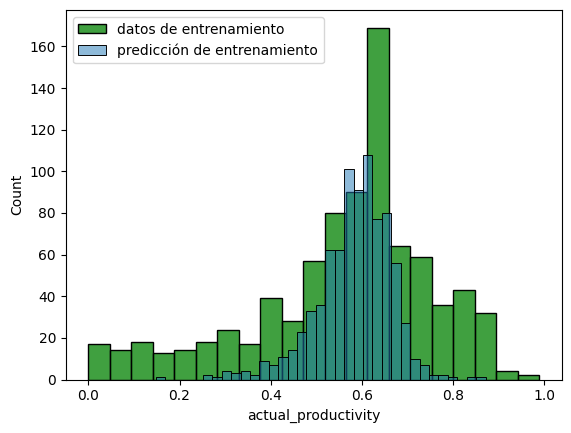

In [23]:
r2_test_1 = r2_score(y_test_des, pred_test_des_1)
rmse_test_1 = root_mean_squared_error(y_test_des, pred_test_des_1)
mae_test_1 = mean_absolute_error(y_test_des, pred_test_des_1)
mape_test_1 = mean_absolute_percentage_error(y_test_des, pred_test_des_1)
print(f'Las métricas de desemepeño en entrenamiento para la regresión lienal son:\nR2: {r2_test_1}\nRMSE: {rmse_test_1}\nMAE: {mae_test_1}\nMAPE: {mape_test_1}')
sb.histplot(data= y_test_des, x= 'actual_productivity',color='green', label='datos de entrenamiento')
sb.histplot(pred_test_des_1, label='predicción de entrenamiento')
plt.legend()
plt.show()

Con la regresión lineal no fuimos capaces de tener un valor con sentido

# **K vecinos más cercanos**

En este caso no nos importa si las vecindades son pares o no. Ante un individuo nuevo, en la variable x se va a lanzar una vecindad con la k que se le indique. K es un hiperparametro. La distancia como segundo hiperparámetro. 

En clasificación k vecinos era la moda de la vecindad.

In [24]:
# k vecinos
modelo_2 = KNeighborsRegressor()
param_grid = {'n_neighbors': [2,3,100,5,12,40,21,35],
              'p':[1,2]}
reg_2 = GridSearchCV(estimator= modelo_2, param_grid= param_grid, cv=3, scoring='neg_mean_absolute_percentage_error')
reg_2.fit(x_train, y_train)
validation = pd.concat([pd.DataFrame(reg_2.cv_results_['params']),
                        pd.DataFrame(reg_2.cv_results_['mean_test_score'], columns=['MAPE'])], axis=1)
validation.sort_values('MAPE', ascending=False)

,n_neighbors,p,MAPE
8,12,1,-0.518559
9,12,2,-0.519614
13,21,2,-0.531775
12,21,1,-0.532395
5,100,2,-0.536088
4,100,1,-0.536460
10,40,1,-0.538999
11,40,2,-0.540343
14,35,1,-0.540659
15,35,2,-0.541200


In [25]:
modelo_2_final= reg_2.best_estimator_
modelo_2_final

,n_neighbors,12
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,1
,metric,'minkowski'
,metric_params,None
,n_jobs,None


Las métricas de desemepeño en entrenamiento para la regresión lienal son:
R2: 0.21266506061465584
RMSE: 0.164112825609797
MAE: 0.1257420216372988
MAPE: 0.4753342221351375


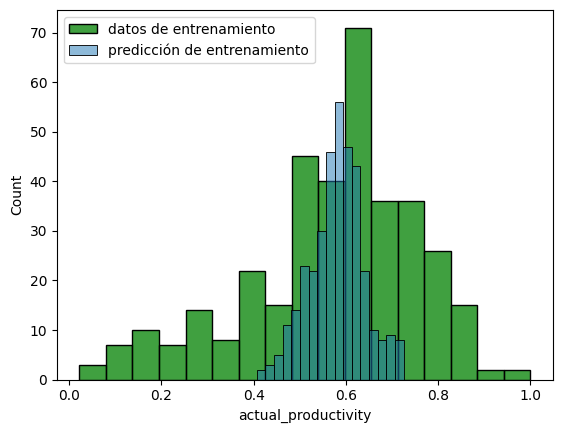

In [26]:
pred_train_2 = modelo_2_final.predict(x_train)
pred_test_2 = modelo_2_final.predict(x_test)
# vamos a desescalar nuestras variables para obtener los valores reales
pred_train_des_2 = pred_train_2 * (np.max(y) - np.min(y)) + np.min(y)
pred_test_des_2 = pred_test_2 * (np.max(y) - np.min(y)) + np.min(y)
y_train_des = y_train * (np.max(y) - np.min(y)) + np.min(y)
y_test_des = y_test * (np.max(y) - np.min(y)) + np.min(y)
r2_train_2 = r2_score(y_train_des, pred_train_des_2)
rmse_train_2 = root_mean_squared_error(y_train_des, pred_train_des_2)
mae_train_2 = mean_absolute_error(y_train_des, pred_train_des_2)
mape_train_2 = mean_absolute_percentage_error(y_train_des, pred_train_des_2)
print(f'Las métricas de desemepeño en entrenamiento para la regresión lienal son:\nR2: {r2_train_2}\nRMSE: {rmse_train_2}\nMAE: {mae_train_2}\nMAPE: {mape_train_2}')
sb.histplot(data= y_train_des, x= 'actual_productivity',color='green', label='datos de entrenamiento')
sb.histplot(pred_train_des_2, label='predicción de entrenamiento')
plt.legend()
plt.show()

Las métricas de desemepeño en prueba para la regresión lienal son:
R2: 0.052272991541549185
RMSE: 0.19482450402507287
MAE: 0.14541600743700445
MAPE: 2984002595612.2764


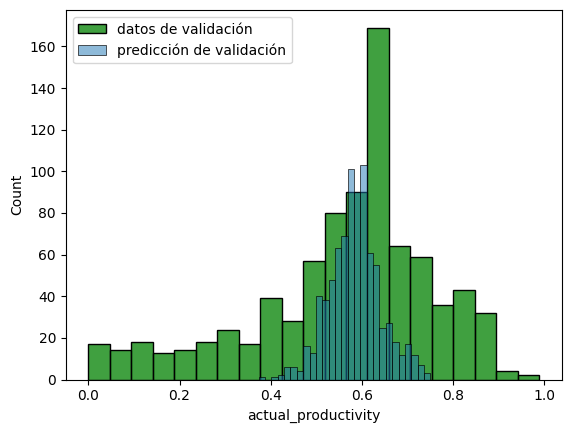

In [27]:
r2_test_2 = r2_score(y_test_des, pred_test_des_2)
rmse_test_2 = root_mean_squared_error(y_test_des, pred_test_des_2)
mae_test_2 = mean_absolute_error(y_test_des, pred_test_des_2)
mape_test_2 = mean_absolute_percentage_error(y_test_des, pred_test_des_2)
print(f'Las métricas de desemepeño en prueba para la regresión lienal son:\nR2: {r2_test_2}\nRMSE: {rmse_test_2}\nMAE: {mae_test_2}\nMAPE: {mape_test_2}')
sb.histplot(data= y_test_des, x= 'actual_productivity',color='green', label='datos de validación')
sb.histplot(pred_test_des_2, label='predicción de validación')
plt.legend()
plt.show()

## **Máquinas de soporte vectorial**

Diseñadas originalmente para clasificadores, no regresores.

Parten del comportamiento del separador lineal. Identificador de hiperplano a través de los soportes, aqui buscan envolver a los individuos, entre mas hayan mejor va a ser. La intención es el mínimo soporte que englobe a la mayor cantidad de individuos. 

c : tasa de erro C > 0

kernel

In [28]:
# Máquinas de soporte vectorial
modelo_3 = SVR()
param_grid = {'C': [0, 0.01, 1, 10, 100], 'kernel': ['linear', 'poly', 'rbf'],'degree':[2,3]}
reg_3 = GridSearchCV(estimator= modelo_3, param_grid= param_grid, cv=3, scoring='neg_mean_absolute_percentage_error')
reg_3.fit(x_train, y_train)
validation = pd.concat([pd.DataFrame(reg_3.cv_results_['params']),
                        pd.DataFrame(reg_3.cv_results_['mean_test_score'], columns=['MAPE'])], axis=1)
validation.sort_values('MAPE', ascending=False)

,C,degree,kernel,MAPE
25,100.00,2,poly,-0.480746
19,10.00,2,poly,-0.487946
27,100.00,3,linear,-0.501471
24,100.00,2,linear,-0.501471
18,10.00,2,linear,-0.502694
21,10.00,3,linear,-0.502694
13,1.00,2,poly,-0.504644
12,1.00,2,linear,-0.505530
15,1.00,3,linear,-0.505530
16,1.00,3,poly,-0.505736


In [29]:
modelo_3_final= reg_3.best_estimator_
modelo_3_final

,kernel,'poly'
,degree,2
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,100
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


Las métricas de desempeño en entrenamiento para la regresión lineal son:
R2: 0.5143411209959112
RMSE: 0.1288927314829555
MAE: 0.09552275227905829
MAPE: 0.3445115023072767


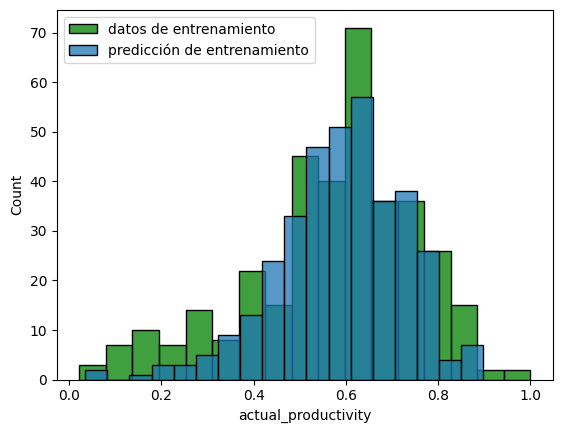

In [30]:
pred_train_3 = modelo_3_final.predict(x_train)
pred_test_3 = modelo_3_final.predict(x_test)
# vamos a desescalar nuestras variables para obtener los valores reales
pred_train_des_3 = pred_train_3 * (np.max(y) - np.min(y)) + np.min(y)
pred_test_des_3 = pred_test_3 * (np.max(y) - np.min(y)) + np.min(y)
y_train_des = y_train * (np.max(y) - np.min(y)) + np.min(y)
y_test_des = y_test * (np.max(y) - np.min(y)) + np.min(y)
r2_train_3 = r2_score(y_train_des, pred_train_des_3)
rmse_train_3 = root_mean_squared_error(y_train_des, pred_train_des_3)
mae_train_3 = mean_absolute_error(y_train_des, pred_train_des_3)
mape_train_3 = mean_absolute_percentage_error(y_train_des, pred_train_des_3)
print(f'Las métricas de desempeño en entrenamiento para la regresión lineal son:\nR2: {r2_train_3}\nRMSE: {rmse_train_3}\nMAE: {mae_train_3}\nMAPE: {mape_train_3}')
sb.histplot(data= y_train_des, x= 'actual_productivity',color='green', label='datos de entrenamiento')
sb.histplot(pred_train_des_3, label='predicción de entrenamiento')
plt.legend()
plt.show()

Las métricas de desemepeño en entrenamiento para la regresión lienal son:
R3: -0.04768867529020793
RMSE: 0.20484156036789905
MAE: 0.15126509744388422
MAPE: 700119621546.683


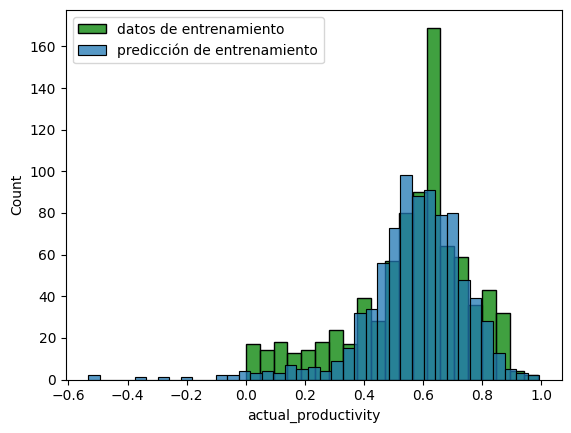

In [31]:
r2_test_3 = r2_score(y_test_des, pred_test_des_3)
rmse_test_3 = root_mean_squared_error(y_test_des, pred_test_des_3)
mae_test_3 = mean_absolute_error(y_test_des, pred_test_des_3)
mape_test_3 = mean_absolute_percentage_error(y_test_des, pred_test_des_3)
print(f'Las métricas de desemepeño en entrenamiento para la regresión lienal son:\nR3: {r2_test_3}\nRMSE: {rmse_test_3}\nMAE: {mae_test_3}\nMAPE: {mape_test_3}')
sb.histplot(data= y_test_des, x= 'actual_productivity',color='green', label='datos de entrenamiento')
sb.histplot(pred_test_des_3, label='predicción de entrenamiento')
plt.legend()
plt.show()

# **Árboles de decisión**

La diferencia con un árbol de clasificación; aquí en regresión lo que va a creae es una zona de respuesta en donde tengo un área posible de respuesta para mi variable y: la búsqueda de ramas pues va a ser a través de un proceso recursivo.

Cada bifurcación que crea el valor es la creación de una región dentro del área de solución.

Va a crecer hasta que en una rama haya un único individuo.

Para una hoja impura, el valor que voy a entregar como predicción es la media, no la moda.

In [32]:
#Árboles de decisión
modelo_4 = DecisionTreeRegressor()
param_grid = {'criterion' : ['squared_error', 'friedman_mse', 'absolute_error', 'poisson'],
              'max_depth': [None], 'min_samples_split': [2,3], 'max_leaf_nodes': [None]}
reg_4 = GridSearchCV(estimator= modelo_4, param_grid= param_grid, cv=3, scoring='neg_mean_absolute_percentage_error')
reg_4.fit(x_train, y_train)
validation = pd.concat([pd.DataFrame(reg_4.cv_results_['params']),
                        pd.DataFrame(reg_4.cv_results_['mean_test_score'], columns=['MAPE'])], axis=1)
validation.sort_values('MAPE', ascending=False)

,criterion,max_depth,max_leaf_nodes,min_samples_split,MAPE
1,squared_error,None,None,3,-0.440518
5,absolute_error,None,None,3,-0.441198
0,squared_error,None,None,2,-0.445319
3,friedman_mse,None,None,3,-0.446428
4,absolute_error,None,None,2,-0.446642
2,friedman_mse,None,None,2,-0.453927
7,poisson,None,None,3,-0.454515
6,poisson,None,None,2,-0.458260


In [33]:
modelo_4_final= reg_4.best_estimator_
modelo_4_final

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,3
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


Las métricas de desemepeño en entrenamiento para la regresión lienal son:
R4: 0.966219383153544
RMSE: 0.033993552160871215
MAE: 0.01370849112703829
MAPE: 0.05891286541323064


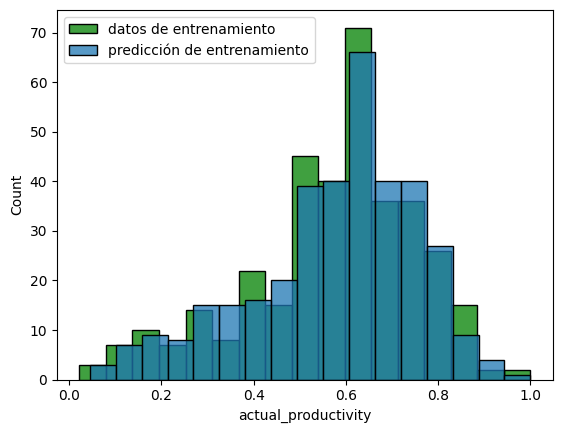

In [34]:
pred_train_4 = modelo_4_final.predict(x_train)
pred_test_4 = modelo_4_final.predict(x_test)
# vamos a desescalar nuestras variables para obtener los valores reales
pred_train_des_4 = pred_train_4 * (np.max(y) - np.min(y)) + np.min(y)
pred_test_des_4 = pred_test_4 * (np.max(y) - np.min(y)) + np.min(y)
y_train_des = y_train * (np.max(y) - np.min(y)) + np.min(y)
y_test_des = y_test * (np.max(y) - np.min(y)) + np.min(y)
r2_train_4 = r2_score(y_train_des, pred_train_des_4)
rmse_train_4 = root_mean_squared_error(y_train_des, pred_train_des_4)
mae_train_4 = mean_absolute_error(y_train_des, pred_train_des_4)
mape_train_4 = mean_absolute_percentage_error(y_train_des, pred_train_des_4)
print(f'Las métricas de desemepeño en entrenamiento para la regresión lienal son:\nR4: {r2_train_4}\nRMSE: {rmse_train_4}\nMAE: {mae_train_4}\nMAPE: {mape_train_4}')
sb.histplot(data= y_train_des, x= 'actual_productivity',color='green', label='datos de entrenamiento')
sb.histplot(pred_train_des_4, label='predicción de entrenamiento')
plt.legend()
plt.show()

Las métricas de desemepeño en entrenamiento para la regresión lienal son:
R4: 0.07464003788779283
RMSE: 0.19251177707952383
MAE: 0.12745702716473142
MAPE: 2838073294983.5356


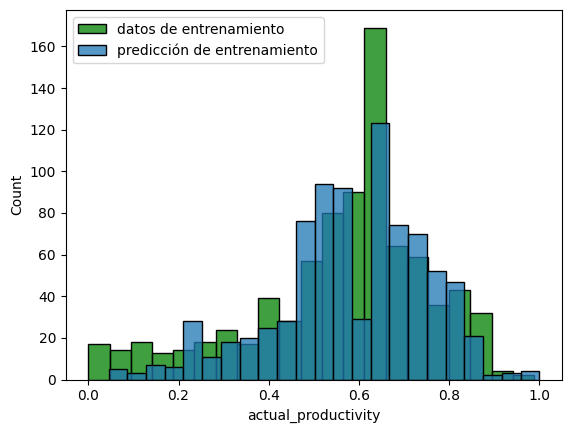

In [35]:
r2_test_4 = r2_score(y_test_des, pred_test_des_4)
rmse_test_4 = root_mean_squared_error(y_test_des, pred_test_des_4)
mae_test_4 = mean_absolute_error(y_test_des, pred_test_des_4)
mape_test_4 = mean_absolute_percentage_error(y_test_des, pred_test_des_4)
print(f'Las métricas de desemepeño en entrenamiento para la regresión lienal son:\nR4: {r2_test_4}\nRMSE: {rmse_test_4}\nMAE: {mae_test_4}\nMAPE: {mape_test_4}')
sb.histplot(data= y_test_des, x= 'actual_productivity',color='green', label='datos de entrenamiento')
sb.histplot(pred_test_des_4, label='predicción de entrenamiento')
plt.legend()
plt.show()

In [36]:
#BOsque aleatorio

modelo_5 = RandomForestRegressor(random_state=123)

param_grid = {'criterion' : [ 'friedman_mse', 'poisson', 'squared_error','absolute_error'],
              'max_depth': [None,5,6,3,4,10,100], 'max_leaf_nodes': [2,3,4,None],'n_estimators': [100,200,300]}
reg_5 = GridSearchCV(estimator= modelo_5, param_grid= param_grid, cv=3, scoring='neg_mean_absolute_percentage_error')
reg_5.fit(x_train, y_train)
validation = pd.concat([pd.DataFrame(reg_5.cv_results_['params']),
                        pd.DataFrame(reg_5.cv_results_['mean_test_score'], columns=['MAPE'])], axis=1)
validation.sort_values('MAPE', ascending=False)


,criterion,max_depth,max_leaf_nodes,n_estimators,MAPE
93,poisson,NaN,NaN,100,-0.390840
165,poisson,100.0,NaN,100,-0.390840
153,poisson,10.0,NaN,100,-0.391470
81,friedman_mse,100.0,NaN,100,-0.392771
9,friedman_mse,NaN,NaN,100,-0.392771
...,...,...,...,...,...
266,absolute_error,5.0,2.0,300,-0.494653
278,absolute_error,6.0,2.0,300,-0.494653
290,absolute_error,3.0,2.0,300,-0.494653
302,absolute_error,4.0,2.0,300,-0.494653


In [37]:
modelo_5_final =reg_5.best_estimator_

modelo_5_final

,n_estimators,100
,criterion,'poisson'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Las métricas de desemepeño en entrenamiento para la regresión lienal son:
R4: 0.9149940321456043
RMSE: 0.05392466664268453
MAE: 0.03631549873243403
MAPE: 0.13556443996676285


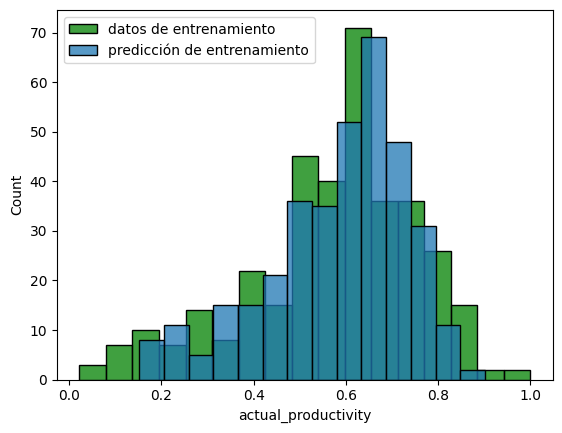

In [38]:
pred_train_5 = modelo_5_final.predict(x_train)
pred_test_5 = modelo_5_final.predict(x_test)
# vamos a desescalar nuestras variables para obtener los valores reales
pred_train_des_5 = pred_train_5 * (np.max(y) - np.min(y)) + np.min(y)
pred_test_des_5 = pred_test_5 * (np.max(y) - np.min(y)) + np.min(y)
y_train_des = y_train * (np.max(y) - np.min(y)) + np.min(y)
y_test_des = y_test * (np.max(y) - np.min(y)) + np.min(y)
r2_train_5 = r2_score(y_train_des, pred_train_des_5)
rmse_train_5 = root_mean_squared_error(y_train_des, pred_train_des_5)
mae_train_5 = mean_absolute_error(y_train_des, pred_train_des_5)
mape_train_5 = mean_absolute_percentage_error(y_train_des, pred_train_des_5)
print(f'Las métricas de desemepeño en entrenamiento para la regresión lienal son:\nR4: {r2_train_5}\nRMSE: {rmse_train_5}\nMAE: {mae_train_5}\nMAPE: {mape_train_5}')
sb.histplot(data= y_train_des, x= 'actual_productivity',color='green', label='datos de entrenamiento')
sb.histplot(pred_train_des_5, label='predicción de entrenamiento')
plt.legend()
plt.show()

Las métricas de desemepeño en entrenamiento para la regresión lienal son:
R4: 0.35768880953674564
RMSE: 0.160389042541724
MAE: 0.10616134095294283
MAPE: 2503542953404.7153


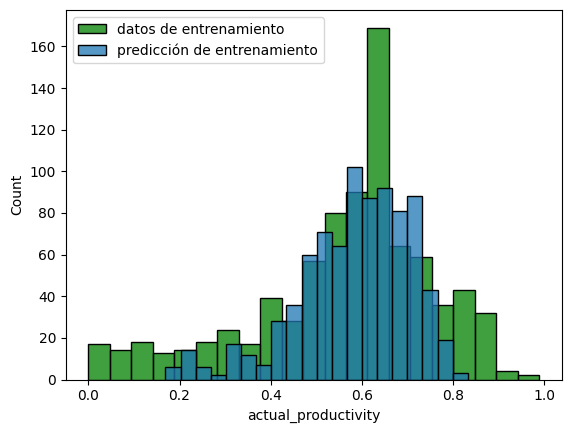

In [39]:
r2_test_5 = r2_score(y_test_des, pred_test_des_5)
rmse_test_5 = root_mean_squared_error(y_test_des, pred_test_des_5)
mae_test_5 = mean_absolute_error(y_test_des, pred_test_des_5)
mape_test_5 = mean_absolute_percentage_error(y_test_des, pred_test_des_5)
print(f'Las métricas de desemepeño en entrenamiento para la regresión lienal son:\nR4: {r2_test_5}\nRMSE: {rmse_test_5}\nMAE: {mae_test_5}\nMAPE: {mape_test_5}')
sb.histplot(data= y_test_des, x= 'actual_productivity',color='green', label='datos de entrenamiento')
sb.histplot(pred_test_des_5, label='predicción de entrenamiento')
plt.legend()
plt.show()

In [40]:
#AdapBoost

modelo_6 = AdaBoostRegressor()

param_grid = {'n_estimators':[100,200,400],'loss':['linear','square','exponential'],'learning_rate':[0.001,0.1,1,10]}

reg_6 = GridSearchCV(estimator=modelo_6,param_grid=param_grid,cv=3,scoring='neg_mean_absolute_percentage_error')

reg_6.fit(x_train,y_train)

validation = pd.concat([pd.DataFrame(reg_6.cv_results_['params']),pd.DataFrame(reg_6.cv_results_['mean_test_score'],columns=['MAPE'])],axis=1)


validation.sort_values('MAPE',ascending=False)

,learning_rate,loss,n_estimators,MAPE
7,0.001,exponential,200,-0.432283
0,0.001,linear,100,-0.434079
1,0.001,linear,200,-0.435516
5,0.001,square,400,-0.435577
15,0.100,exponential,100,-0.435689
2,0.001,linear,400,-0.437717
9,0.100,linear,100,-0.438139
8,0.001,exponential,400,-0.439419
4,0.001,square,200,-0.440182
10,0.100,linear,200,-0.441606


In [41]:
modelo_6_final =reg_6.best_estimator_

modelo_6_final

,estimator,None
,n_estimators,200
,learning_rate,0.001
,loss,'exponential'
,random_state,None


Las métricas de desemepeño en entrenamiento para la regresión lienal son:
R4: 0.4284764906370979
RMSE: 0.13982338460497107
MAE: 0.09841823127078485
MAPE: 0.3872861201490141


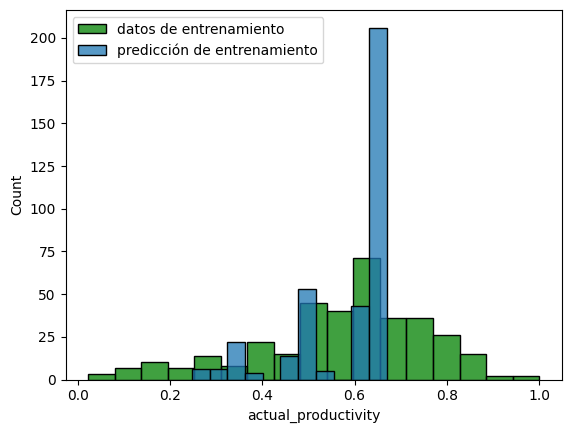

In [42]:
pred_train_6 = modelo_6_final.predict(x_train)
pred_test_6 = modelo_6_final.predict(x_test)
# vamos a desescalar nuestras variables para obtener los valores reales
pred_train_des_6 = pred_train_6 * (np.max(y) - np.min(y)) + np.min(y)
pred_test_des_6 = pred_test_6 * (np.max(y) - np.min(y)) + np.min(y)
y_train_des = y_train * (np.max(y) - np.min(y)) + np.min(y)
y_test_des = y_test * (np.max(y) - np.min(y)) + np.min(y)
r2_train_6 = r2_score(y_train_des, pred_train_des_6)
rmse_train_6 = root_mean_squared_error(y_train_des, pred_train_des_6)
mae_train_6 = mean_absolute_error(y_train_des, pred_train_des_6)
mape_train_6 = mean_absolute_percentage_error(y_train_des, pred_train_des_6)
print(f'Las métricas de desemepeño en entrenamiento para la regresión lienal son:\nR4: {r2_train_6}\nRMSE: {rmse_train_6}\nMAE: {mae_train_6}\nMAPE: {mape_train_6}')
sb.histplot(data= y_train_des, x= 'actual_productivity',color='green', label='datos de entrenamiento')
sb.histplot(pred_train_des_6, label='predicción de entrenamiento')
plt.legend()
plt.show()

Las métricas de desemepeño en entrenamiento para la regresión lienal son:
R4: 0.2364575038442045
RMSE: 0.1748713075308756
MAE: 0.11776403035500876
MAPE: 2742778945650.7603


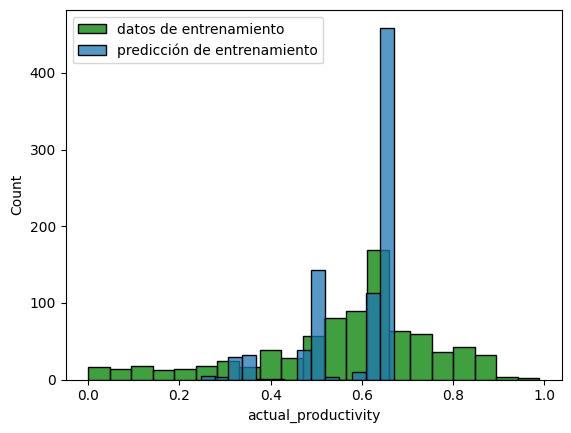

In [43]:
r2_test_6 = r2_score(y_test_des, pred_test_des_6)
rmse_test_6 = root_mean_squared_error(y_test_des, pred_test_des_6)
mae_test_6 = mean_absolute_error(y_test_des, pred_test_des_6)
mape_test_6 = mean_absolute_percentage_error(y_test_des, pred_test_des_6)
print(f'Las métricas de desemepeño en entrenamiento para la regresión lienal son:\nR4: {r2_test_6}\nRMSE: {rmse_test_6}\nMAE: {mae_test_6}\nMAPE: {mape_test_6}')
sb.histplot(data= y_test_des, x= 'actual_productivity',color='green', label='datos de entrenamiento')
sb.histplot(pred_test_des_6, label='predicción de entrenamiento')
plt.legend()
plt.show()

In [44]:
#modelo 7: Gradient Boosting

modelo_7 = GradientBoostingRegressor()

param_grid = {'n_estimators':[100,200,400,500,1000],'loss':['squared_error','absolute_error'],'criterion':['friedman_mse','squared_error']}

reg_7_r = RandomizedSearchCV(estimator=modelo_7,param_distributions =param_grid,cv=3,scoring='neg_mean_absolute_percentage_error',n_iter=10, n_jobs=-1)

reg_7_r.fit(x_train,y_train)

validation = pd.concat([pd.DataFrame(reg_7_r.cv_results_['params']),pd.DataFrame(reg_7_r.cv_results_['mean_test_score'],columns=['MAPE'])],axis=1)


validation.sort_values('MAPE',ascending=False)

,n_estimators,loss,criterion,MAPE
8,100,squared_error,squared_error,-0.371830
1,100,squared_error,friedman_mse,-0.376792
4,500,absolute_error,friedman_mse,-0.377526
3,1000,absolute_error,friedman_mse,-0.383154
5,400,absolute_error,friedman_mse,-0.385861
2,500,squared_error,squared_error,-0.386894
7,1000,squared_error,squared_error,-0.391002
9,500,squared_error,friedman_mse,-0.391898
0,100,absolute_error,squared_error,-0.396686
6,100,absolute_error,friedman_mse,-0.402303


In [45]:
#Gradient boosting grid search


modelo_7 = GradientBoostingRegressor()

param_grid = {'n_estimators':[100,200,400,500,1000],'loss':['squared_error','absolute_error'],'criterion':['friedman_mse','squared_error']}

reg_7 = GridSearchCV(estimator=modelo_7,param_grid=param_grid,cv=3,scoring='neg_mean_absolute_percentage_error')
reg_7.fit(x_train,y_train)
validation = pd.concat([pd.DataFrame(reg_7.cv_results_['params']),pd.DataFrame(reg_7.cv_results_['mean_test_score'],columns=['MAPE'])],axis=1)
validation.sort_values('MAPE',ascending=False)


,criterion,loss,n_estimators,MAPE
0,friedman_mse,squared_error,100,-0.372449
10,squared_error,squared_error,100,-0.374849
17,squared_error,absolute_error,400,-0.377769
1,friedman_mse,squared_error,200,-0.378098
7,friedman_mse,absolute_error,400,-0.378586
11,squared_error,squared_error,200,-0.378657
19,squared_error,absolute_error,1000,-0.379548
9,friedman_mse,absolute_error,1000,-0.380705
8,friedman_mse,absolute_error,500,-0.381978
18,squared_error,absolute_error,500,-0.384474


In [46]:
modelo_7_final =reg_7.best_estimator_
modelo_7_final

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


Las métricas de desemepeño en entrenamiento para larbol de decision son:
R4: 0.7950754808304644
RMSE: 0.08372588043574021
MAE: 0.05683967543898061
MAPE: 0.21164749954870332


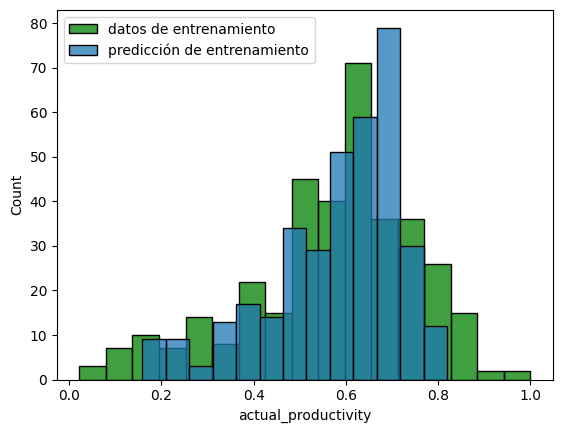

In [47]:
pred_train_7 = modelo_7_final.predict(x_train)
pred_test_7 = modelo_7_final.predict(x_test)
# vamos a desescalar nuestras variables para obtener los valores reales
pred_train_des_7 = pred_train_7 * (np.max(y) - np.min(y)) + np.min(y)
pred_test_des_7 = pred_test_7 * (np.max(y) - np.min(y)) + np.min(y)
y_train_des = y_train * (np.max(y) - np.min(y)) + np.min(y)
y_test_des = y_test * (np.max(y) - np.min(y)) + np.min(y)
r2_train_7 = r2_score(y_train_des, pred_train_des_7)
rmse_train_7 = root_mean_squared_error(y_train_des, pred_train_des_7)
mae_train_7 = mean_absolute_error(y_train_des, pred_train_des_7)
mape_train_7 = mean_absolute_percentage_error(y_train_des, pred_train_des_7)
print(f'Las métricas de desemepeño en entrenamiento para larbol de decision son:\nR4: {r2_train_7}\nRMSE: {rmse_train_7}\nMAE: {mae_train_7}\nMAPE: {mape_train_7}')
sb.histplot(data= y_train_des, x= 'actual_productivity',color='green', label='datos de entrenamiento')
sb.histplot(pred_train_des_7, label='predicción de entrenamiento')
plt.legend()
plt.show()

Las métricas de desemepeño en entrenamiento para la arbol de decision son:
R4: 0.4151214951856774
RMSE: 0.15305050994347397
MAE: 0.1030573997486547
MAPE: 2698669192848.5386


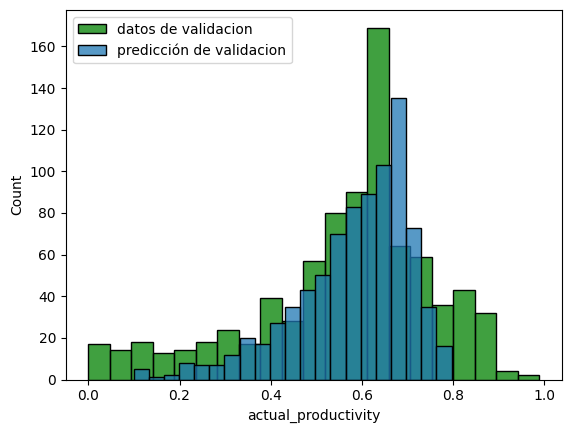

In [48]:
r2_test_7 = r2_score(y_test_des, pred_test_des_7)
rmse_test_7 = root_mean_squared_error(y_test_des, pred_test_des_7)
mae_test_7 = mean_absolute_error(y_test_des, pred_test_des_7)
mape_test_7 = mean_absolute_percentage_error(y_test_des, pred_test_des_7)
print(f'Las métricas de desemepeño en entrenamiento para la arbol de decision son:\nR4: {r2_test_7}\nRMSE: {rmse_test_7}\nMAE: {mae_test_7}\nMAPE: {mape_test_7}')
sb.histplot(data= y_test_des, x= 'actual_productivity',color='green', label='datos de validacion')
sb.histplot(pred_test_des_7, label='predicción de validacion')
plt.legend()
plt.show()

In [49]:

#Modelo 8: Red neuronal
#hiperparámetros
#Numero de capas Oculatas
#Numero de neuronas por capa oculta
#función de activación
#Tasa de Aprendizaje
#iteraciones
#Optimizador (como se hace la derivada)



#Perceptor multicapa


modelo_8 = MLPRegressor(random_state=123)


param_grid = {'hidden_layer_sizes': [(10,), (10,10), (10,10,10), (20,10)],
              'activation': [ 'logistic', 'tanh', 'relu'], 'learning_rate_init': [0.001, 0.01, 0.1],
              'solver': ['lbfgs', 'sgd', 'adam'], 'max_iter': [200,300,400]}
reg_8 = GridSearchCV(estimator= modelo_8, param_grid= param_grid, cv=3, scoring='neg_mean_absolute_percentage_error', n_jobs=-1)
reg_8.fit(x_train, y_train)
validation = pd.concat([pd.DataFrame(reg_8.cv_results_['params']),
                        pd.DataFrame(reg_8.cv_results_['mean_test_score'], columns=['MAPE'])], axis=1)
validation.sort_values('MAPE', ascending=False)


,activation,hidden_layer_sizes,learning_rate_init,max_iter,solver,MAPE
81,logistic,"(20, 10)",0.001,200,lbfgs,-0.472481
90,logistic,"(20, 10)",0.010,200,lbfgs,-0.472481
99,logistic,"(20, 10)",0.100,200,lbfgs,-0.472481
126,tanh,"(10,)",0.100,200,lbfgs,-0.474375
117,tanh,"(10,)",0.010,200,lbfgs,-0.474375
...,...,...,...,...,...,...
136,tanh,"(10, 10)",0.001,200,sgd,-0.629985
142,tanh,"(10, 10)",0.001,400,sgd,-0.629985
250,relu,"(10, 10)",0.001,400,sgd,-0.656236
244,relu,"(10, 10)",0.001,200,sgd,-0.656236


In [50]:
modelo_8_final = reg_8.best_estimator_
modelo_8_final

,loss,'squared_error'
,hidden_layer_sizes,"(20, ...)"
,activation,'logistic'
,solver,'lbfgs'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,200
,shuffle,True


Las métricas de desemepeño en entrenamiento para larbol de decision son:
R4: 0.44420766875909357
RMSE: 0.13788563891894848
MAE: 0.097999894267443
MAPE: 0.3605686555706971


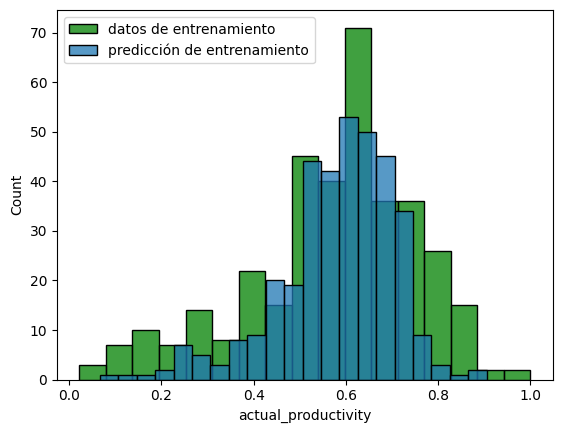

In [51]:
pred_train_8 = modelo_8_final.predict(x_train)
pred_test_8 = modelo_8_final.predict(x_test)
# vamos a desescalar nuestras variables para obtener los valores reales
pred_train_des_8 = pred_train_8 * (np.max(y) - np.min(y)) + np.min(y)
pred_test_des_8 = pred_test_8 * (np.max(y) - np.min(y)) + np.min(y)
y_train_des = y_train * (np.max(y) - np.min(y)) + np.min(y)
y_test_des = y_test * (np.max(y) - np.min(y)) + np.min(y)
r2_train_8 = r2_score(y_train_des, pred_train_des_8)
rmse_train_8 = root_mean_squared_error(y_train_des, pred_train_des_8)
mae_train_8 = mean_absolute_error(y_train_des, pred_train_des_8)
mape_train_8 = mean_absolute_percentage_error(y_train_des, pred_train_des_8)
print(f'Las métricas de desemepeño en entrenamiento para larbol de decision son:\nR4: {r2_train_8}\nRMSE: {rmse_train_8}\nMAE: {mae_train_8}\nMAPE: {mape_train_8}')
sb.histplot(data= y_train_des, x= 'actual_productivity',color='green', label='datos de entrenamiento')
sb.histplot(pred_train_des_8, label='predicción de entrenamiento')
plt.legend()
plt.show()

Las métricas de desemepeño en entrenamiento para la regresión lienal son:
R4: 0.131857089530645
RMSE: 0.18646510158800286
MAE: 0.12961979457350992
MAPE: 2222753125427.023


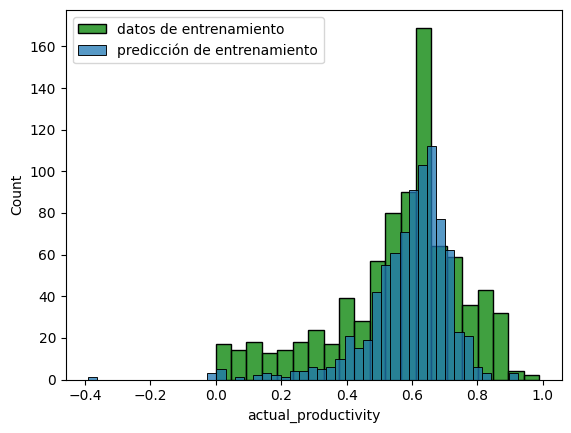

In [52]:
r2_test_8 = r2_score(y_test_des, pred_test_des_8)
rmse_test_8 = root_mean_squared_error(y_test_des, pred_test_des_8)
mae_test_8 = mean_absolute_error(y_test_des, pred_test_des_8)
mape_test_8 = mean_absolute_percentage_error(y_test_des, pred_test_des_8)
print(f'Las métricas de desemepeño en entrenamiento para la regresión lienal son:\nR4: {r2_test_8}\nRMSE: {rmse_test_8}\nMAE: {mae_test_8}\nMAPE: {mape_test_8}')
sb.histplot(data= y_test_des, x= 'actual_productivity',color='green', label='datos de entrenamiento')
sb.histplot(pred_test_des_8, label='predicción de entrenamiento')
plt.legend()
plt.show()